Maiya J. & Natasha Y.
DATA 303
Project Milestone 2/3

In [204]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [205]:
ds_sal = pd.read_csv('ds_salaries.csv', index_col= 0)

In [206]:
ds_sal.head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L
5,2020,EN,FT,Data Analyst,72000,USD,72000,US,100,US,L
6,2020,SE,FT,Lead Data Scientist,190000,USD,190000,US,100,US,S
7,2020,MI,FT,Data Scientist,11000000,HUF,35735,HU,50,HU,L
8,2020,MI,FT,Business Data Analyst,135000,USD,135000,US,100,US,L
9,2020,SE,FT,Lead Data Engineer,125000,USD,125000,NZ,50,NZ,S


In [207]:
ds_sal.columns = ds_sal.columns.str.strip()

In [208]:
ds_sal = ds_sal.drop(columns = ['salary', 'salary_currency', 'employee_residence'])
ds_sal.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,79833,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,0,JP,S
2,2020,SE,FT,Big Data Engineer,109024,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,50,US,L


In [209]:
ds_sal['job_title'].unique()

<StringArray>
[                          'Data Scientist',
               'Machine Learning Scientist',
                        'Big Data Engineer',
                     'Product Data Analyst',
                'Machine Learning Engineer',
                             'Data Analyst',
                      'Lead Data Scientist',
                    'Business Data Analyst',
                       'Lead Data Engineer',
                        'Lead Data Analyst',
                            'Data Engineer',
                  'Data Science Consultant',
                          'BI Data Analyst',
                 'Director of Data Science',
                       'Research Scientist',
                 'Machine Learning Manager',
                 'Data Engineering Manager',
 'Machine Learning Infrastructure Engineer',
                              'ML Engineer',
                             'AI Scientist',
                 'Computer Vision Engineer',
                 'Principal Data Scientis

In [210]:
ds_sal['experience_level'].unique()

<StringArray>
['MI', 'SE', 'EN', 'EX']
Length: 4, dtype: str

In [211]:
ds_sal['experience_level'] = ds_sal['experience_level'].replace({
    'EN': 'Entry',
    'MI': 'Mid',
    'SE': 'Senior',
    'EX': 'Executive'
})

In [212]:
ds_sal['employment_type'].unique()

<StringArray>
['FT', 'CT', 'PT', 'FL']
Length: 4, dtype: str

In [213]:
ds_sal = ds_sal[ds_sal['employment_type'] == 'FT']
ds_sal.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_location,company_size
0,2020,Mid,FT,Data Scientist,79833,0,DE,L
1,2020,Senior,FT,Machine Learning Scientist,260000,0,JP,S
2,2020,Senior,FT,Big Data Engineer,109024,50,GB,M
3,2020,Mid,FT,Product Data Analyst,20000,0,HN,S
4,2020,Senior,FT,Machine Learning Engineer,150000,50,US,L


In [214]:
ds_sal['remote_ratio'].unique()

array([  0,  50, 100])

In [215]:
ds_sal['remote_ratio'] = ds_sal['remote_ratio'].replace({
    0: 'In-person',
    50: 'Hybrid',
    100: 'Remote'
})

ds_sal = ds_sal.rename(columns = {"remote_ratio": "work_setting"})
ds_sal.head(20)

,work_year,experience_level,employment_type,job_title,salary_in_usd,work_setting,company_location,company_size
0,2020,Mid,FT,Data Scientist,79833,In-person,DE,L
1,2020,Senior,FT,Machine Learning Scientist,260000,In-person,JP,S
2,2020,Senior,FT,Big Data Engineer,109024,Hybrid,GB,M
3,2020,Mid,FT,Product Data Analyst,20000,In-person,HN,S
4,2020,Senior,FT,Machine Learning Engineer,150000,Hybrid,US,L
5,2020,Entry,FT,Data Analyst,72000,Remote,US,L
6,2020,Senior,FT,Lead Data Scientist,190000,Remote,US,S
7,2020,Mid,FT,Data Scientist,35735,Hybrid,HU,L
8,2020,Mid,FT,Business Data Analyst,135000,Remote,US,L
9,2020,Senior,FT,Lead Data Engineer,125000,Hybrid,NZ,S


In [216]:
len(ds_sal)

588

In [217]:
#Rewriting locations to be compatible with Tableau
ds_sal['company_location'].unique() 
ds_sal['company_location'] = ds_sal['company_location'].replace({
    'DE': 'Germany', 'JP': 'Japan', 'GB': 'United Kingdom', 'HN': 'Honduras',
    'US': 'United States', 'HU': 'Hungary', 'NZ': 'New Zealand', 'FR': 'France',
    'IN': 'India', 'PK': 'Pakistan', 'CN': 'China', 'GR': 'Greece',
    'AE': 'United Arab Emirates', 'NL': 'Netherlands', 'MX': 'Mexico',
    'CA': 'Canada', 'AT': 'Austria', 'NG': 'Nigeria', 'ES': 'Spain',
    'PT': 'Portugal', 'DK': 'Denmark', 'HR': 'Croatia', 'LU': 'Luxembourg',
    'PL': 'Poland', 'SG': 'Singapore', 'RO': 'Romania', 'IQ': 'Iraq',
    'BR': 'Brazil', 'BE': 'Belgium', 'UA': 'Ukraine', 'IL': 'Israel',
    'RU': 'Russia', 'MT': 'Malta', 'CL': 'Chile', 'IR': 'Iran',
    'CO': 'Colombia', 'MD': 'Moldova', 'KE': 'Kenya', 'SI': 'Slovenia',
    'CH': 'Switzerland', 'VN': 'Vietnam', 'AS': 'American Samoa',
    'TR': 'Turkey', 'CZ': 'Czech Republic', 'IT': 'Italy', 'EE': 'Estonia',
    'MY': 'Malaysia', 'AU': 'Australia', 'IE': 'Ireland'
}
)
ds_sal.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,work_setting,company_location,company_size
0,2020,Mid,FT,Data Scientist,79833,In-person,Germany,L
1,2020,Senior,FT,Machine Learning Scientist,260000,In-person,Japan,S
2,2020,Senior,FT,Big Data Engineer,109024,Hybrid,United Kingdom,M
3,2020,Mid,FT,Product Data Analyst,20000,In-person,Honduras,S
4,2020,Senior,FT,Machine Learning Engineer,150000,Hybrid,United States,L


In [218]:
ds_sal.to_csv('cleaned_ds_salaries.csv', index=False)

In [219]:
avg_salary_el = ds_sal.groupby('experience_level')['salary_in_usd'].mean()

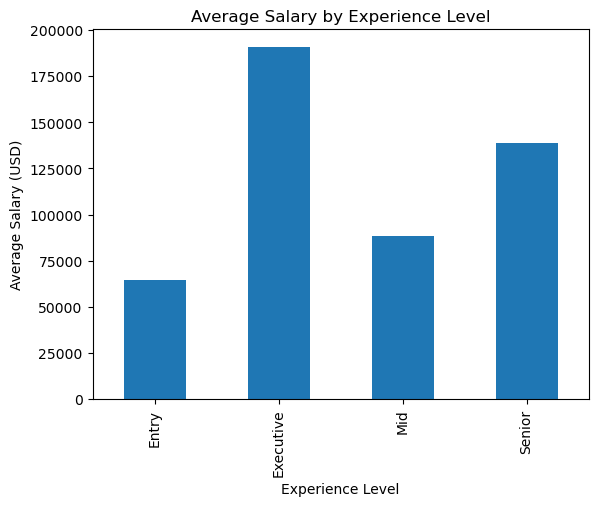

In [220]:
avg_salary_el.plot(kind = 'bar')

plt.title('Average Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary (USD)')

plt.show()

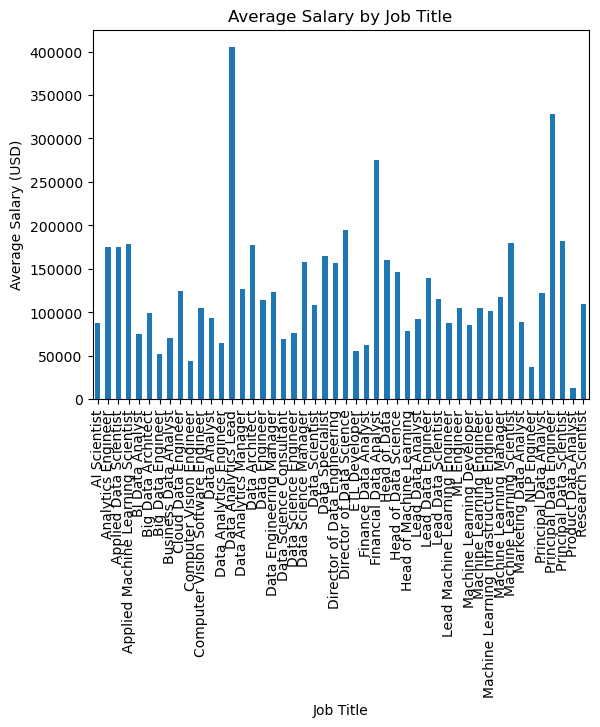

In [221]:
avg_salary_jt = ds_sal.groupby('job_title')['salary_in_usd'].mean()
avg_salary_jt.plot(kind = 'bar')

plt.title('Average Salary by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Average Salary (USD)')

plt.show()

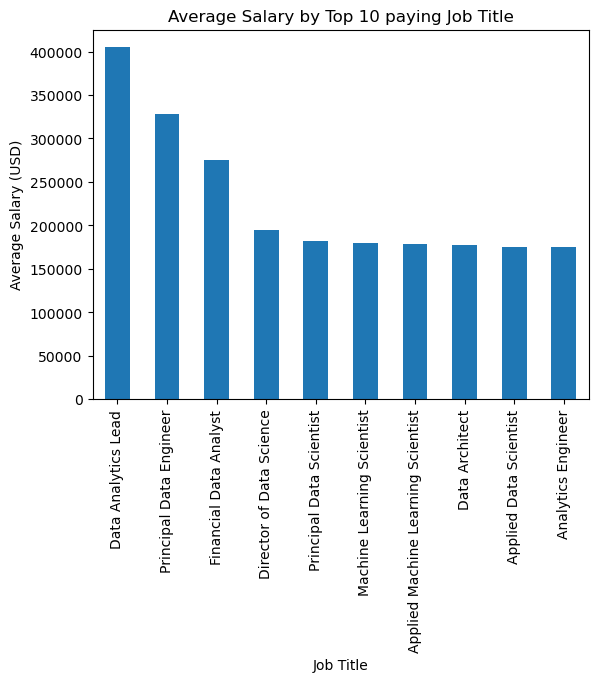

In [222]:
top_10 = avg_salary_jt.sort_values(ascending= False).head(10)
top_10.plot(kind = 'bar')

plt.title('Average Salary by Top 10 paying Job Title')
plt.xlabel('Job Title')
plt.ylabel('Average Salary (USD)')

plt.show()

In [223]:
country = 'United States'

country_us = ds_sal[ds_sal['company_location'] == country]

top5_jobs = (



SyntaxError: incomplete input (3990868698.py, line 6)